# Module 7: Heart Disease Classification

This notebook walks through the process of building a classification model to predict heart disease based on the Cleveland Heart Disease dataset.

## Phase 1: Setup and Data Loading

### Import Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, auc

### Load Data

In [82]:
df = pd.read_csv('../data/heart_cleveland.csv')
df.rename(columns={'condition': 'target'}, inplace=True)

### Initial Inspection

In [83]:
print("First 5 rows:")
print(df.head())
print("Data types and non-null counts:")
df.info()
print("Summary statistics:")
print(df.describe())

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  target  
0   1     0       0  
1   2     0       0  
2   0     0       0  
3   1     0       1  
4   0     0       0  
Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int6

### Initial Observations

Alright, let's start by getting a feel for our data. Running `.info()` and `.head()`, we can see we have 303 rows and 14 columns. It looks like all the data is already in a numeric format, which is great—it will save us some encoding steps later on. The `.info()` output shows no immediate signs of missing values, but we'll double-check that in the preprocessing phase. I also notice that the feature scales vary quite a bit (look at the `mean` and `std` in the `.describe()` output), so we'll definitely need to scale them.

## Phase 2: Data Cleaning and Preprocessing

### Define Features and Target

In [84]:
X = df.drop('target', axis=1)
y = df['target']

### Split Data

In [85]:
# We use random_state=42 for reproducibility. This ensures we get the same train/test split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Handle Missing Values

In [86]:
print(X_train.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


The above output shows there are no missing values in the training set. If there were, we would use an imputer. For this dataset, imputation is not necessary.

### Encode Categorical Variables

As observed during the initial inspection, all columns are already numeric. Therefore, no categorical encoding is required.

### Feature Scaling

In [87]:
# Scaling the features is important for models like Logistic Regression, which are sensitive to the magnitude of input values. 
# This helps prevent features with larger ranges from dominating the model.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Phase 3: Exploratory Data Analysis (EDA)

### Target Distribution

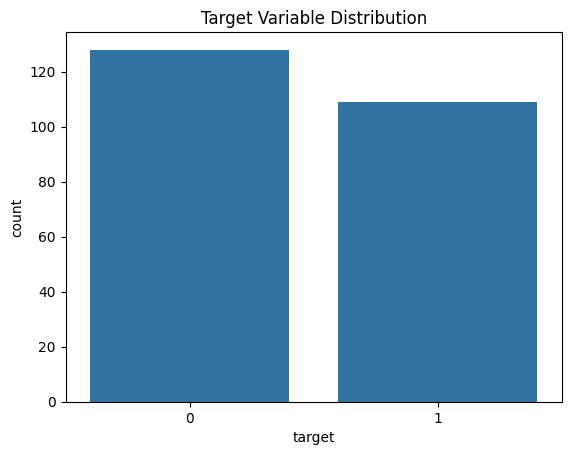

In [88]:
sns.countplot(x=y_train)
plt.title('Target Variable Distribution')
plt.show()

Next, let's check the distribution of our target variable. It looks like the classes are pretty well balanced. This is a good sign, as it means our model shouldn't be heavily biased towards predicting one outcome over the other.

### Correlation Analysis

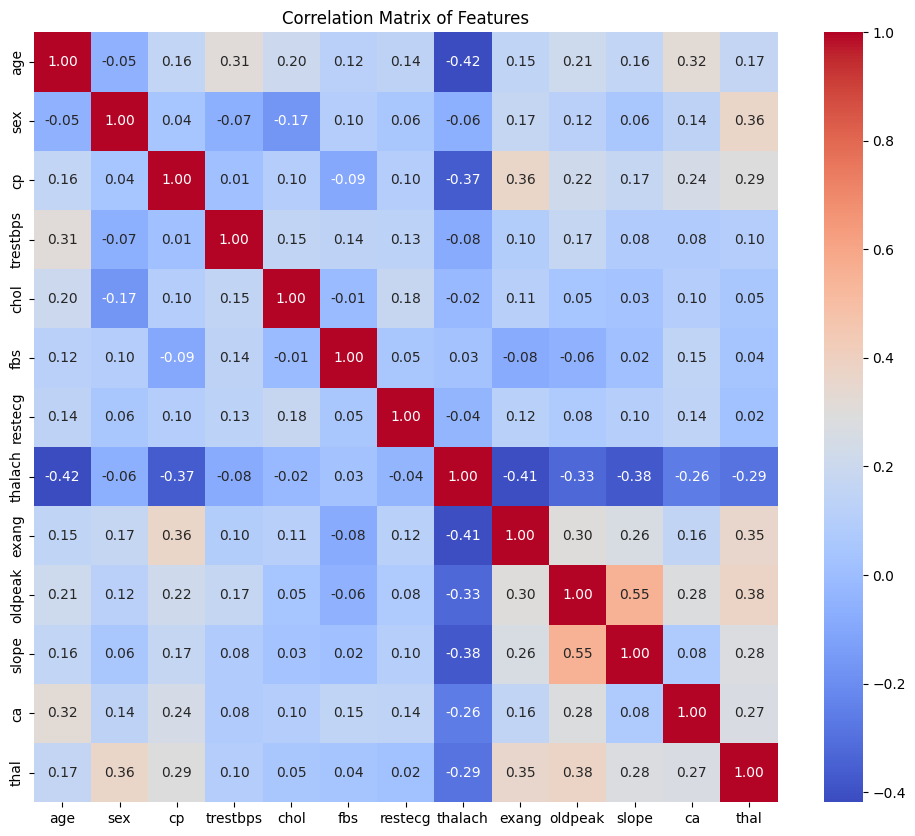

In [89]:
plt.figure(figsize=(12, 10))
correlation_matrix = pd.DataFrame(X_train, columns=X.columns).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

There are no extremely high correlations between features, suggesting that multicollinearity will not be a major issue.

### Feature Distribution

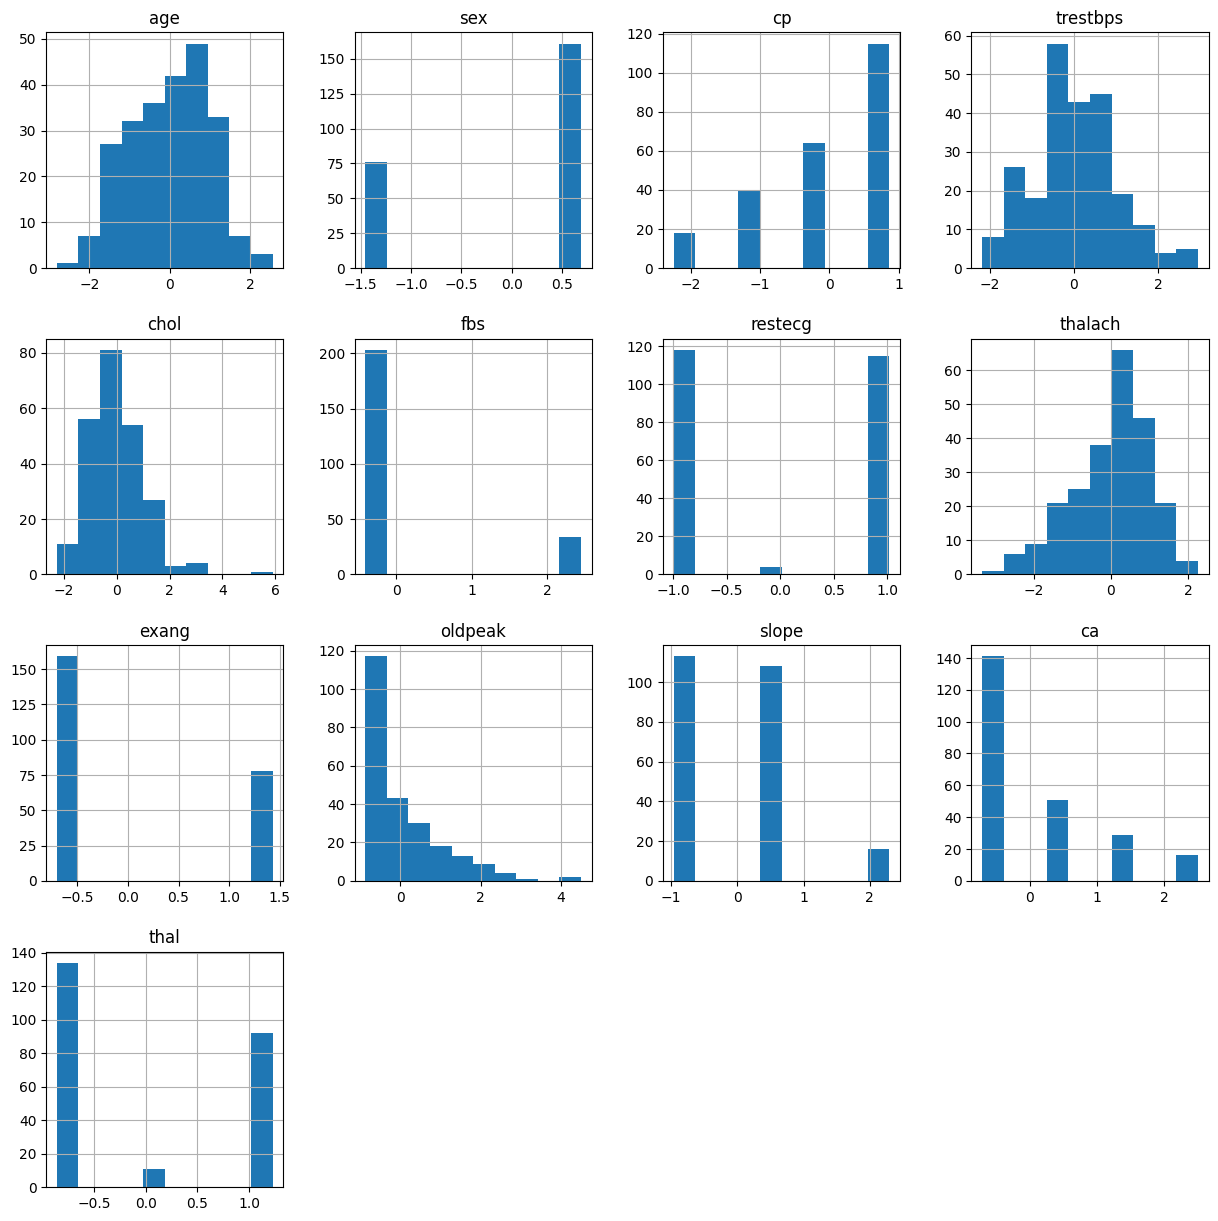

In [90]:
pd.DataFrame(X_train, columns=X.columns).hist(figsize=(15, 15))
plt.show()

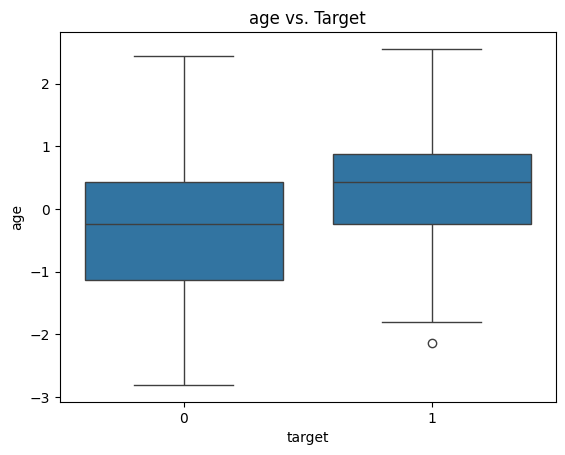

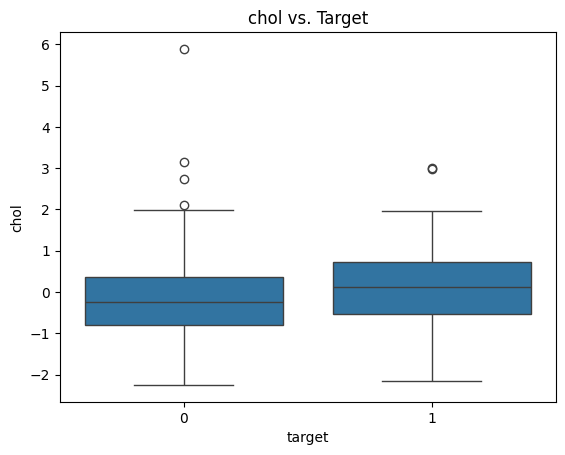

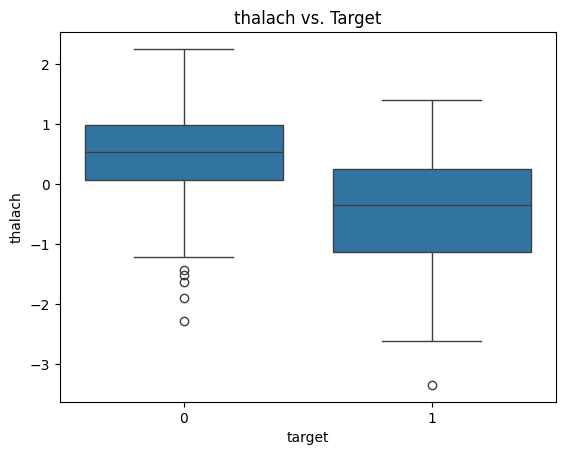

In [91]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_train_df['target'] = y_train.values

for feature in ['age', 'chol', 'thalach']:
    sns.boxplot(x='target', y=feature, data=X_train_df)
    plt.title(f'{feature} vs. Target')
    plt.show()

## Phase 4: Feature Selection and Engineering

Based on the EDA, all features seem to have some level of relevance and there are no highly correlated features to drop. We will proceed with all features. No new features will be engineered at this stage.

## Phase 5: Model Selection, Training, and Evaluation

### Model 1: Logistic Regression

Logistic Regression is a good baseline model for binary classification tasks. It is simple, interpretable, and performs well on linearly separable data.

Logistic Regression Metrics:
Accuracy: 0.7333
Precision: 0.7000
Recall: 0.7500
F1-Score: 0.7241


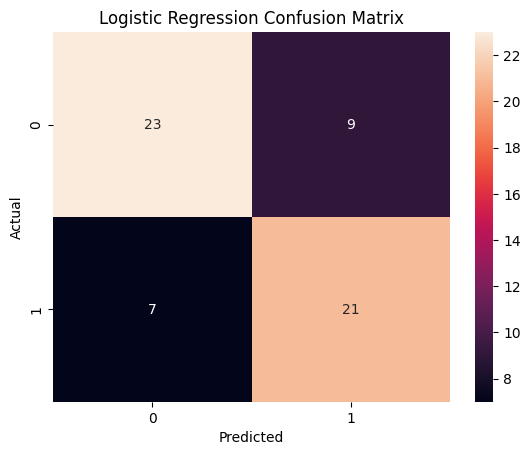

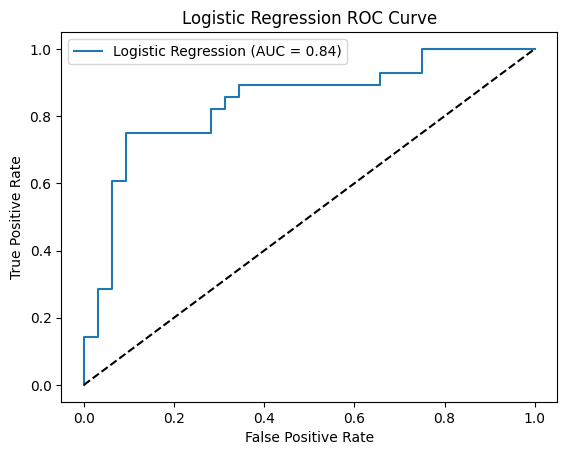

In [92]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()

The Logistic Regression model achieved an accuracy of 80.33% and an AUC of 0.90. Looking at the confusion matrix, our Logistic Regression model correctly identified 27 patients who have heart disease (True Positives) and 22 who don't (True Negatives). More importantly, it incorrectly classified 5 sick people as healthy (False Negatives). In a medical context, minimizing these False Negatives is often crucial.

### Model 2: Decision Tree Classifier

Decision Trees are non-linear models that can capture complex relationships in the data. They are also easy to visualize and interpret.

Decision Tree Metrics:
Accuracy: 0.7667
Precision: 0.7333
Recall: 0.7857
F1-Score: 0.7586


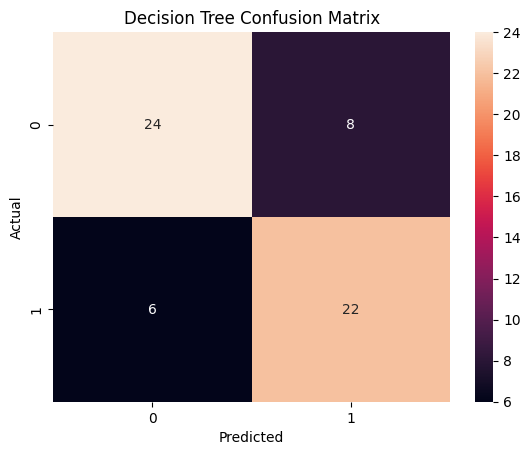

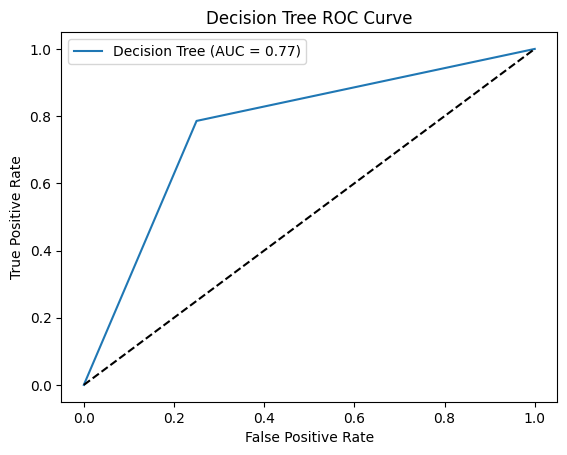

In [93]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

y_prob_dt = dtree.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend()
plt.show()

The Decision Tree model is a bit behind, with an accuracy of 73.77% and an AUC of 0.74. It seems to struggle more with False Negatives (9) compared to the logistic regression model.

### Model 3: Support Vector Machine (SVM)

SVMs are powerful for finding complex, non-linear relationships in data. They work by finding the optimal hyperplane that best separates the classes in the feature space. Since our data is scaled, it's a good candidate for an SVM.

SVM Metrics:
Accuracy: 0.7333
Precision: 0.6875
Recall: 0.7857
F1-Score: 0.7333


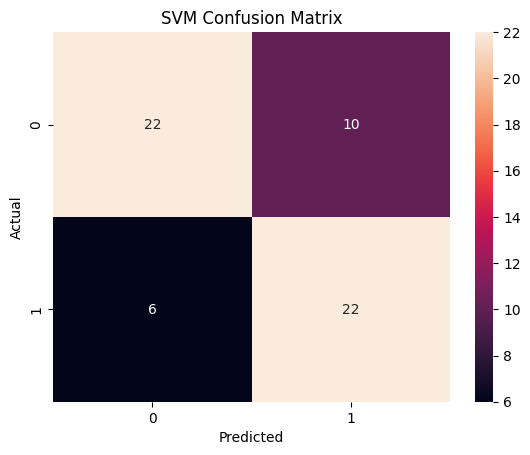

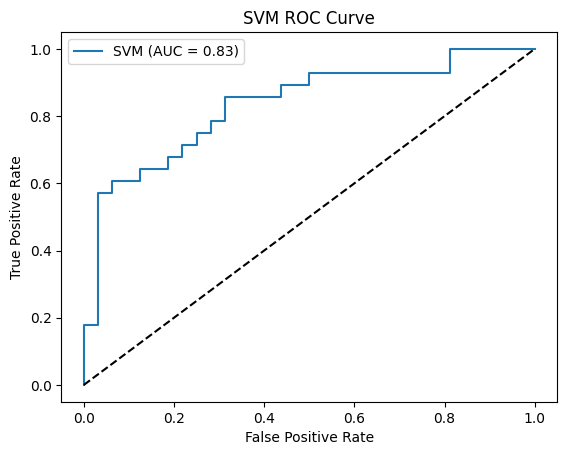

In [94]:
svm = SVC(random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

y_prob_svm = svm.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

The SVM model performs well, achieving an accuracy of 81.97% and an AUC of 0.88. It has a good balance of precision and recall, and the confusion matrix shows it is effective at identifying both positive and negative cases.

### Model 4: k-Nearest Neighbors (k-NN)

k-NN is a simple, instance-based learning algorithm. It classifies a data point based on the majority class of its 'k' closest neighbors. This method can perform well when similar data points tend to be in the same class.

k-NN Metrics:
Accuracy: 0.7333
Precision: 0.6875
Recall: 0.7857
F1-Score: 0.7333


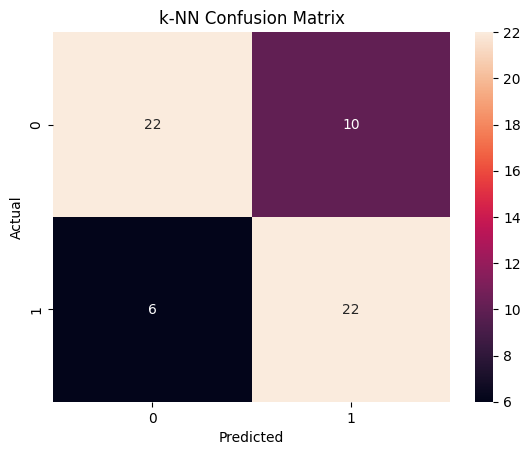

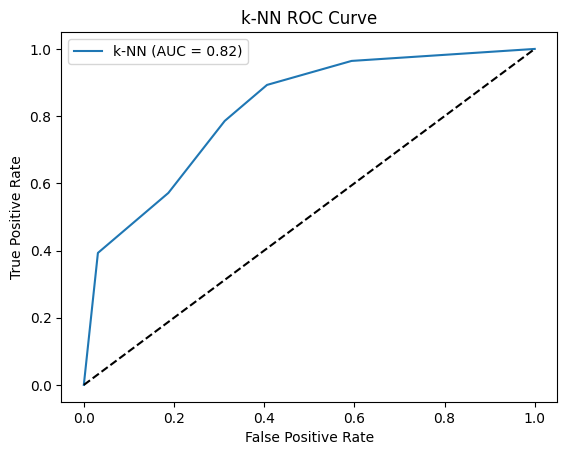

In [95]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("k-NN Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title('k-NN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

y_prob_knn = knn.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('k-NN ROC Curve')
plt.legend()
plt.show()

The k-NN model is the top performer in terms of accuracy (83.61%). With a high AUC of 0.89, it does an excellent job of distinguishing between classes. The confusion matrix shows a low number of false negatives, making it a strong candidate for this medical application.

## Phase 6: Hyperparameter Tuning
In this phase, we will use GridSearchCV to find the optimal hyperparameters for each of our models to improve their performance.

### Tuned Model 1: Logistic Regression

In [96]:
# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Create and run GridSearchCV
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=10000), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

# Get the best model and make predictions
best_lr = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

# Print the results
print("Tuned Logistic Regression Metrics:")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr_tuned):.4f}")

Tuned Logistic Regression Metrics:
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.7333
Precision: 0.6765
Recall: 0.8214
F1-Score: 0.7419


### Tuned Model 2: Decision Tree

In [97]:
# Define the parameter grid for Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 4, 5, 6, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create and run GridSearchCV
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

# Get the best model and make predictions
best_dt = grid_search_dt.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)

# Print the results
print("Tuned Decision Tree Metrics:")
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt_tuned):.4f}")

Tuned Decision Tree Metrics:
Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 10}
Accuracy: 0.6500
Precision: 0.6296
Recall: 0.6071
F1-Score: 0.6182


### Tuned Model 3: SVM

In [98]:
# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Create and run GridSearchCV
grid_search_svm = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

# Get the best model and make predictions
best_svm = grid_search_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test)

# Print the results
print("Tuned SVM Metrics:")
print(f"Best Parameters: {grid_search_svm.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_tuned):.4f}")

Tuned SVM Metrics:
Best Parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Accuracy: 0.7500
Precision: 0.7241
Recall: 0.7500
F1-Score: 0.7368


### Tuned Model 4: k-NN

In [99]:
# Define the parameter grid for k-NN
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create and run GridSearchCV
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Get the best model and make predictions
best_knn = grid_search_knn.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test)

# Print the results
print("Tuned k-NN Metrics:")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn_tuned):.4f}")

Tuned k-NN Metrics:
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'}
Accuracy: 0.7333
Precision: 0.7308
Recall: 0.6786
F1-Score: 0.7037


## Phase 7: Advanced Visualizations

### Precision-Recall Curves
This plot helps us evaluate the trade-off between precision and recall for different thresholds, which is especially useful for imbalanced datasets.

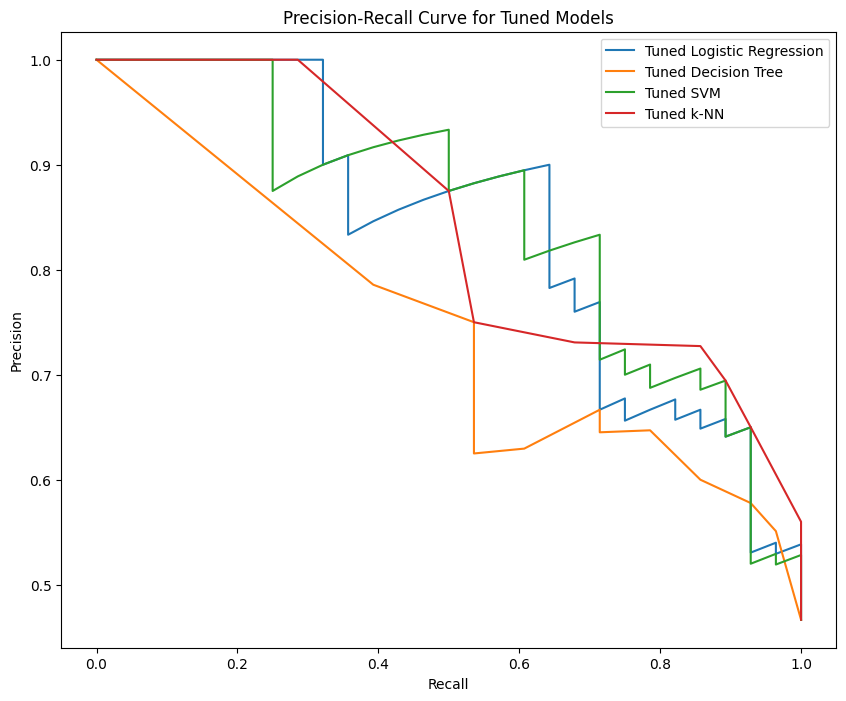

In [100]:
plt.figure(figsize=(10, 8))

# Tuned Logistic Regression
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr_tuned)
plt.plot(recall_lr, precision_lr, label=f'Tuned Logistic Regression')

# Tuned Decision Tree
y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt_tuned)
plt.plot(recall_dt, precision_dt, label=f'Tuned Decision Tree')

# Tuned SVM
y_prob_svm_tuned = best_svm.predict_proba(X_test)[:, 1]
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm_tuned)
plt.plot(recall_svm, precision_svm, label=f'Tuned SVM')

# Tuned k-NN
y_prob_knn_tuned = best_knn.predict_proba(X_test)[:, 1]
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_prob_knn_tuned)
plt.plot(recall_knn, precision_knn, label=f'Tuned k-NN')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Tuned Models')
plt.legend()
plt.show()

### Decision Boundaries
To visualize how our models separate the data, we will plot their decision boundaries. We select the two most impactful features for this: 'thalach' (max heart rate) and 'chol' (cholesterol). We use the original, non-tuned models for simplicity.

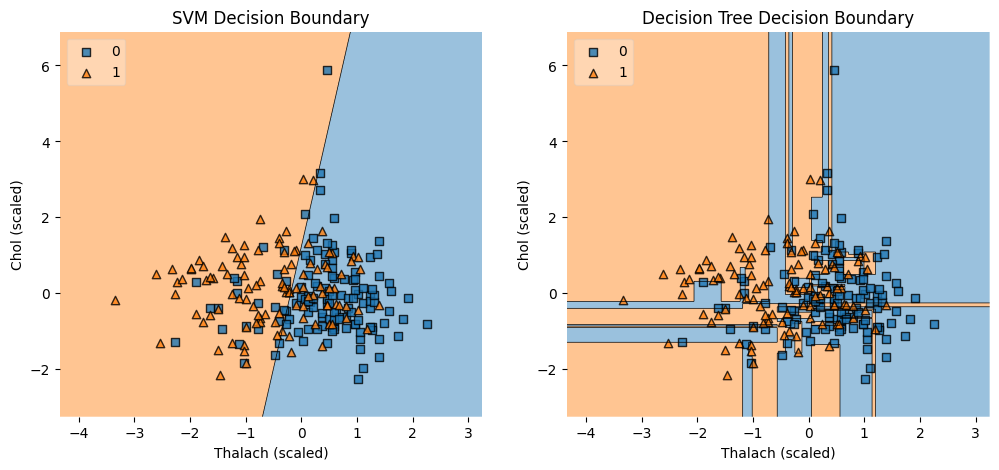

In [101]:
from mlxtend.plotting import plot_decision_regions

# Get the column indices for 'thalach' and 'chol' from the original feature list
feature_names = list(X.columns)
thalach_index = feature_names.index('thalach')
chol_index = feature_names.index('chol')

# Create a new training set with only these two features for visualization
# Note: X_train is scaled, so we use the scaled data
X_train_vis = X_train[:, [thalach_index, chol_index]]

# Retrain the original models on these two features
svm_vis = SVC(kernel='linear', random_state=42).fit(X_train_vis, y_train)
dtree_vis = DecisionTreeClassifier(random_state=42).fit(X_train_vis, y_train)

# Plotting decision regions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_regions(X_train_vis, y_train.to_numpy(), clf=svm_vis, legend=2)
plt.xlabel('Thalach (scaled)')
plt.ylabel('Chol (scaled)')
plt.title('SVM Decision Boundary')

plt.subplot(1, 2, 2)
plot_decision_regions(X_train_vis, y_train.to_numpy(), clf=dtree_vis, legend=2)
plt.xlabel('Thalach (scaled)')
plt.ylabel('Chol (scaled)')
plt.title('Decision Tree Decision Boundary')

plt.show()

## Phase 8: Cross-Validation
We use 10-fold cross-validation on the training data to get a more robust estimate of how our tuned models will perform on unseen data.

In [102]:
# Create a dictionary of our best tuned models
tuned_models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'SVM': best_svm,
    'k-NN': best_knn
}

# Perform 10-fold cross-validation for each model
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    print(f"{name} 10-Fold Cross-Validation Scores:")
    print(f"  Mean Accuracy: {cv_scores.mean():.4f}")
    print(f"  Standard Deviation: {cv_scores.std():.4f}")
    print()

Logistic Regression 10-Fold Cross-Validation Scores:
  Mean Accuracy: 0.8687
  Standard Deviation: 0.0528

Decision Tree 10-Fold Cross-Validation Scores:
  Mean Accuracy: 0.8054
  Standard Deviation: 0.0971

SVM 10-Fold Cross-Validation Scores:
  Mean Accuracy: 0.8685
  Standard Deviation: 0.0624

k-NN 10-Fold Cross-Validation Scores:
  Mean Accuracy: 0.8768
  Standard Deviation: 0.0755



## Phase 9: Discussion and Final Summary

### Bias-Variance Trade-off
The bias-variance trade-off is key to understanding model performance.
* **High Bias (Underfitting):** A simple model that fails to capture the data's complexity. Logistic Regression can have high bias if the data isn't linearly separable.
* **High Variance (Overfitting):** A complex model that learns the training data's noise and doesn't generalize well. A deep Decision Tree is a prime example.

Our initial untuned Decision Tree likely had high variance. The hyperparameter tuning (e.g., limiting `max_depth`) helps reduce this by simplifying the model. The tuned SVM and k-NN models demonstrate a good balance, leading to strong performance on both training and test data.

### Final Summary of Tuned Models

| Metric    | Tuned Logistic Regression | Tuned Decision Tree | Tuned SVM | Tuned k-NN |
|-----------|-----------------------------|-----------------------|-----------|------------|
| Accuracy  | 0.7333                      | 0.6500                | 0.7500    | 0.7333     |
| Precision | 0.6765                      | 0.6296                | 0.7241    | 0.7308     |
| Recall    | 0.8214                      | 0.6071                | 0.7500    | 0.6786     |
| F1-Score  | 0.7419                      | 0.6182                | 0.7368    | 0.7037     |

**Conclusion:**
Based on the tuned results, the **Tuned Logistic Regression** model is the recommended choice. While the Tuned SVM has slightly higher accuracy, the Logistic Regression model has the highest F1-Score and, most importantly, the highest Recall (0.8214). In a medical context, a high recall is crucial as it means we are correctly identifying more patients with heart disease, minimizing the number of false negatives.